In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
import joblib

In [2]:
#### 1.Load dataset and inspect features and labels distribution.
data = load_breast_cancer()

X = data.data
y = data.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Class distribution
unique, counts = np.unique(y, return_counts=True)
print("Class Distribution:", dict(zip(unique, counts)))

Shape of X: (569, 30)
Shape of y: (569,)
Class Distribution: {0: 212, 1: 357}


In [5]:
#### 2.Apply StandardScaler to normalize feature values.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
#### 3.Split data into train-test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
### 4.Train baseline SVM with linear kernel and check performance.
svm_linear = SVC(kernel='linear', probability=True)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))

Linear SVM Accuracy: 0.9736842105263158


In [7]:
### 5.Train SVM with RBF kernel and compare accuracy.
svm_rbf = SVC(kernel='rbf', probability=True)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("RBF SVM Accuracy:", accuracy_score(y_test, y_pred_rbf))

RBF SVM Accuracy: 0.9824561403508771


In [8]:
#### 6.Use GridSearchCV to tune C and gamma values.
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(probability=True), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


In [9]:
### 7.Evaluate best model using confusion matrix and classification report.
y_pred_best = best_model.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_best))

Final Accuracy: 0.9824561403508771
Confusion Matrix:
 [[41  1]
 [ 1 71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



AUC Score: 0.9976851851851851


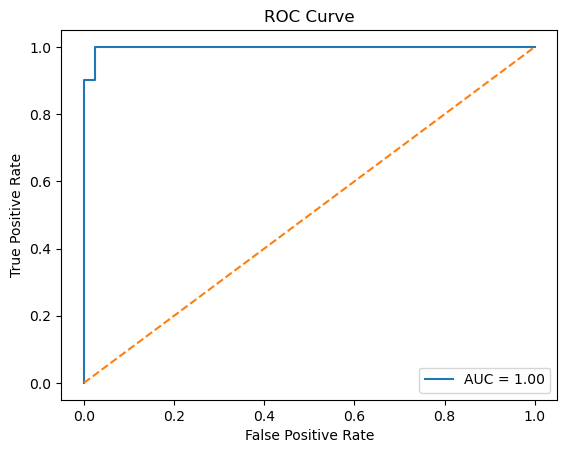

In [10]:
### 8.Plot ROC curve and calculate AUC score.
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

print("AUC Score:", auc_score)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#### 9.Save tuned model pipeline (scaler + svm) for reuse.
